[   9   21   31   33   37   39   49   49   51   53   55   73   73   79
   81   83   85   91  101  105  105  107  107  111  117  117  125  129
  129  137  145  155  163  163  173  173  183  193  203  205  213  229
  235  237  241  243  247  251  253  259  259  265  265  289  299  323
  343  343  345  347  349  351  363  369  391  407  411  437  443  443
  445  461  477  519  529  543  543  557  583  585  603  613  615  627
  649  677  691  741  759  763  781  781  815  841  891  913  935 1109
 1193 1201]
337.6516
292.8295931381253
0.8672536814222865
-362.53516130136677
0.6667894721031189
336.54712


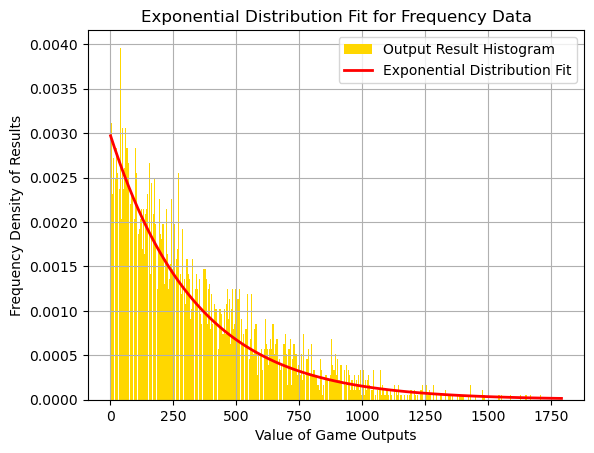

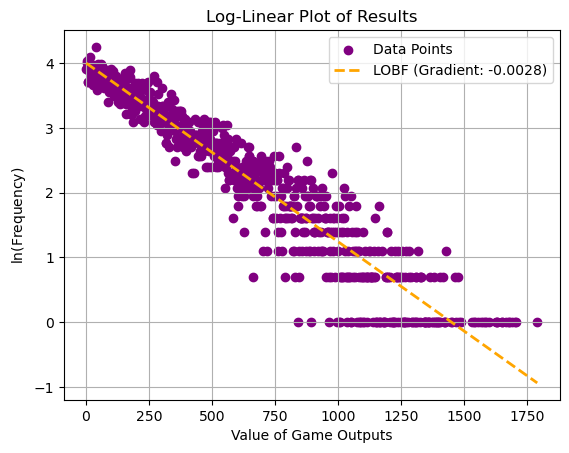

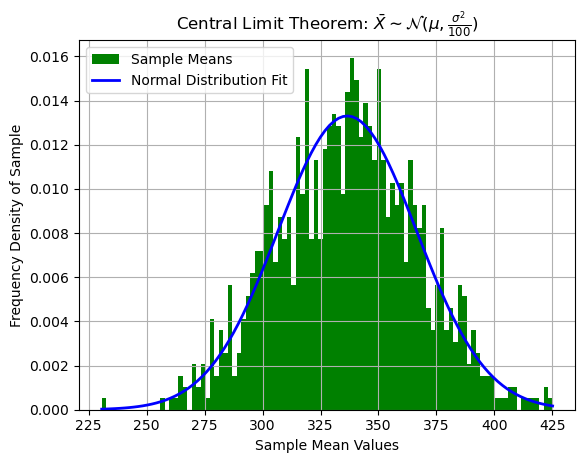

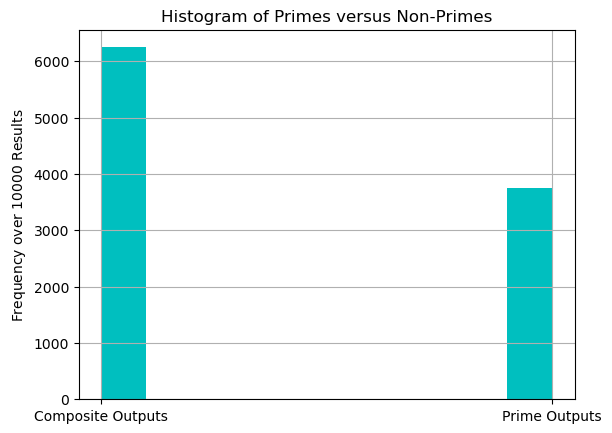

In [92]:
import numpy as np
import random
import matplotlib.pyplot as plt
import sympy as sp
from scipy.stats import expon, norm, shapiro

n = int(2026)
ntrials = int(10000)
sampsize = int(100)
nsamp = int(1000)

# I am paranoid of incorrect data types so the int() makes me feel better.

def game(n):
    papers = []
    for i in range(n):
        papers += [i+1]
    
    while len(papers) >= 2:
        choice1 = np.random.choice(papers)
        papers.remove(choice1)
        choice2 = np.random.choice(papers)
        papers.remove(choice2)
        papers.append(int(abs(choice1 - choice2)))
            
    return papers[0]

def gameFaster(n):
    papers = []
    for i in range(n):
        papers.append(i+1)
    
    while len(papers) >= 2:
        choice1 = random.randrange(len(papers))
        a = papers.pop(choice1)
        choice2 = random.randrange(len(papers))
        b = papers.pop(choice2)
        papers.append(int(abs(a - b)))
        
    return papers[0]

def trial(n, size):
    trials = []
    for j in range(size):
        trials.append(gameFaster(n))
    triarr = np.array(trials)
    return np.sort(triarr)

def prime(data):
    primes = []
    for i in range(len(data)):
        primes.append(sp.isprime(data[i]))
    primarr = np.array(primes).astype(int)
    return primarr

# for the purposes of a gameFurther() example output.
print(trial(n, 100))
#
trial1 = trial(n, ntrials)
print(np.mean(trial1))
print(np.std(trial1))
cv = np.std(trial1) / np.mean(trial1)
print(cv)
prime1 = prime(trial1)
loc, scale = expon.fit(trial1)
xExp = np.linspace(min(trial1), max(trial1), 100)

counts, edges = np.histogram(trial1, bins=int(n/2))
centres = (edges[:-1] + edges[1:])/2
mask = counts > 0
xLog = centres[mask]
yLog = np.log(counts[mask])
grad, intercept = np.polyfit(xLog, yLog, 1)
lobf = grad * xLog + intercept
print(1/grad)

sampmeans = []
for j in range(nsamp):
    collection = np.random.choice(trial1, size=sampsize, replace=True)
    colmean = np.mean(collection)
    sampmeans.append(colmean)
    
mu, sigma = norm.fit(sampmeans)
xNorm = np.linspace(min(sampmeans), max(sampmeans), 100)
shap, p2 = shapiro(sampmeans)
print(p2)
print(np.mean(sampmeans))
    
plt.hist(trial1, bins=int(n/2), density=True, color='gold', label='Output Result Histogram')
plt.plot(xExp, expon.pdf(xExp, loc, scale), lw=2, color='r', label='Exponential Distribution Fit')
plt.grid(True)
plt.title('Exponential Distribution Fit for Frequency Data')
plt.xlabel('Value of Game Outputs')
plt.ylabel('Frequency Density of Results')
plt.legend()
plt.show()

plt.scatter(xLog, yLog, color='purple', label='Data Points')
plt.plot(xLog, lobf, color='orange', ls='--', lw=2, label=f'LOBF (Gradient: {grad:.4f})')
plt.grid(True)
plt.title('Log-Linear Plot of Results')
plt.xlabel('Value of Game Outputs')
plt.ylabel(r'$\ln(\mathrm{Frequency})$')
plt.legend()
plt.show()

plt.hist(sampmeans, bins=100, density=True, color='g', label='Sample Means')
plt.plot(xNorm, norm.pdf(xNorm, mu, sigma), lw=2, color='b', label='Normal Distribution Fit')
plt.grid(True)
plt.title(r'Central Limit Theorem: $\bar{X} \sim \mathcal{N}(\mu, \frac{\sigma^2}{100})$')
plt.xlabel('Sample Mean Values')
plt.ylabel('Frequency Density of Sample')
plt.legend()
plt.show()

plt.hist(prime1, color='c')
plt.grid(True)
plt.title('Histogram of Primes versus Non-Primes')
plt.xticks([0, 1], ['Composite Outputs', 'Prime Outputs'])
plt.ylabel(r'Frequency over $10000$ Results')
plt.show()